In [1]:
%load_ext dotenv
%dotenv

In [2]:
import langchain
import groq
import os

from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from typing import Literal, Annotated
from langchain_groq import ChatGroq
from langchain_core.runnables import Runnable
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, RemoveMessage
from collections.abc import Sequence

In [3]:
my_list = add_messages([AIMessage("What is your question?"), 
                        HumanMessage("Could you tell me a grook by Piet Hein?"),
                        AIMessage("Certainly! Here's a well-known grook by Piet Hein..."),
                        AIMessage("Would you like to ask one more question?"),
                        HumanMessage("yes"),
                        AIMessage("What is your question?"),
                        HumanMessage("Where was the poet born?"),
                        AIMessage("Piet Hein was born in Copenhagen, Denmark, on December 16, 1905."),
                        AIMessage("Would you like to ask one more question?")],
                       [HumanMessage("yes")]
                      )

In [4]:
my_list[:-5]

[AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='d340dd75-7c66-4b77-80e1-8466b8590a39', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Could you tell me a grook by Piet Hein?', additional_kwargs={}, response_metadata={}, id='3c811183-2ade-4fe4-9b01-5c86ed8a4981'),
 AIMessage(content="Certainly! Here's a well-known grook by Piet Hein...", additional_kwargs={}, response_metadata={}, id='51074964-525a-4491-9a9c-fb866cab1241', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Would you like to ask one more question?', additional_kwargs={}, response_metadata={}, id='2a1920d3-c314-443f-9ebf-0ccd6c852e09', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='909e513e-0536-429c-8052-241429fcf586')]

In [5]:
remove_messages = [RemoveMessage(id = i.id) for i in my_list[:-5]]

In [6]:
remove_messages

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='d340dd75-7c66-4b77-80e1-8466b8590a39'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='3c811183-2ade-4fe4-9b01-5c86ed8a4981'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='51074964-525a-4491-9a9c-fb866cab1241'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2a1920d3-c314-443f-9ebf-0ccd6c852e09'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='909e513e-0536-429c-8052-241429fcf586')]

In [7]:
add_messages(my_list, remove_messages)

[AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='1f0dd03b-8a32-4c2a-8b31-671830fa0575', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Where was the poet born?', additional_kwargs={}, response_metadata={}, id='7f70951f-43da-4c7c-b7a2-a93d11e4174d'),
 AIMessage(content='Piet Hein was born in Copenhagen, Denmark, on December 16, 1905.', additional_kwargs={}, response_metadata={}, id='b99ea9b8-ad7f-4228-b32c-a1014875144d', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Would you like to ask one more question?', additional_kwargs={}, response_metadata={}, id='4bc99447-b164-4317-bc7a-bbc97049b559', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='d4134bbf-4bc9-4357-bcbe-24c10981ed91')]

In [31]:
chat = ChatGroq(
    model_name="llama-3.1-8b-instant",  # Groq model
    temperature=0,
    max_tokens=100,
    groq_api_key=os.getenv("GROQ_API_KEY"),  # remove if already set globally
)

In [32]:
def trim_messages(state: MessagesState) -> MessagesState:
    print(f"\n------> ENTERING trim messages:")
    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:-5]]
    return MessagesState(messages = remove_messages)

In [33]:
def ask_question(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING ask_question:")
    for i in state["messages"]:
        i.pretty_print()
    question = "What is your question?"
    print(question)
    return MessagesState(messages = [AIMessage(question), HumanMessage(input())])

In [34]:
def chatbot(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING chatbot:")
    for i in state["messages"]:
        i.pretty_print()
        
    response = chat.invoke(state["messages"]) 
    response.pretty_print()

    return MessagesState(messages = [response])

In [35]:
def ask_another_question(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING ask_another_question:")
    for i in state["messages"]:
        i.pretty_print()
    question = "What you like to ask one more question? (yes/no)"
    print(question)
    return MessagesState(messages = [AIMessage(question), HumanMessage(input())])

In [36]:
from typing import Literal

def routing_function(state: MessagesState) -> Literal["trim_messages", "__end__"]:
    last_message = state["messages"][-1]
    
    if last_message.content == 'yes':
        return "trim_messages"
    else:
        return "__end__"

In [37]:
graph = StateGraph(MessagesState)

In [38]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("trim_messages", trim_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_edge("trim_messages", "ask_question")
graph.add_conditional_edges(source = "ask_another_question", path = routing_function)

In [39]:
graph_compiled = graph.compile()

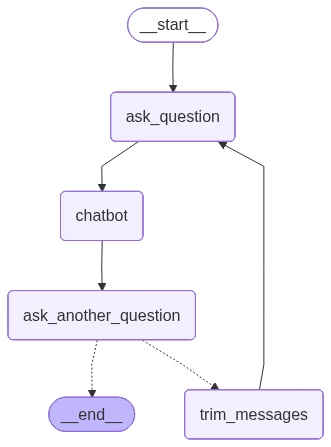

In [40]:
graph_compiled

In [41]:
graph_compiled.invoke(MessagesState(messages = []))


-------> ENTERING ask_question:
What is your question?


 Could you give me a grook by Piet hein?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Could you give me a grook by Piet hein?
================================== Ai Message ==================================

Piet Hein was a Danish poet, mathematician, and inventor. He is known for his short, witty poems called "grooks." Here's one:

"Life is always a ritual
Of the unexpected, the usual.
The usual is what we expect
The unexpected is what we get."

I hope you enjoy it.

-------> ENTERING ask_another_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Could you give me a grook by Piet hein?
================================== Ai Message ==================================

Piet Hein was a Danish poet, mathematician, and i

 yes



------> ENTERING trim messages:

-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Could you give me a grook by Piet hein?
================================== Ai Message ==================================

Piet Hein was a Danish poet, mathematician, and inventor. He is known for his short, witty poems called "grooks." Here's one:

"Life is always a ritual
Of the unexpected, the usual.
The usual is what we expect
The unexpected is what we get."

I hope you enjoy it.
================================== Ai Message ==================================

What you like to ask one more question? (yes/no)
================================ Human Message =================================

yes
What is your question?


...


------> ENTERING trim messages:

-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What else did he do ?
================================== Ai Message ==================================

Piet Hein was a Danish poet, inventor, and mathematician. He is best known for his 'Grooks', which are short, witty poems that often deal with everyday life and human nature. He also invented the 'Samspilsbrikker' (a type of sliding puzzle) and the 'Kanboard' (a type of board game).

Additionally, Piet Hein was a prolific writer and published many books of poetry and essays. He was also a popular public speaker and was known
================================== Ai Message ==================================

What you like to ask one more question? (yes/no)
================================ Human Message =================================

y

 Do you remember the grook you told me ?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What else did he do ?
================================== Ai Message ==================================

Piet Hein was a Danish poet, inventor, and mathematician. He is best known for his 'Grooks', which are short, witty poems that often deal with everyday life and human nature. He also invented the 'Samspilsbrikker' (a type of sliding puzzle) and the 'Kanboard' (a type of board game).

Additionally, Piet Hein was a prolific writer and published many books of poetry and essays. He was also a popular public speaker and was known
================================== Ai Message ==================================

What you like to ask one more question? (yes/no)
================================ Human Message =================================

yes
================================== 

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='cc81a46b-7ef1-4fcc-9ed9-aed287e8f5bd', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What else did he do ?', additional_kwargs={}, response_metadata={}, id='70f4e5d0-eeb0-411a-8837-a190c56c17f8'),
  AIMessage(content="Piet Hein was a Danish poet, inventor, and mathematician. He is best known for his 'Grooks', which are short, witty poems that often deal with everyday life and human nature. He also invented the 'Samspilsbrikker' (a type of sliding puzzle) and the 'Kanboard' (a type of board game).\n\nAdditionally, Piet Hein was a prolific writer and published many books of poetry and essays. He was also a popular public speaker and was known", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 122, 'total_tokens': 222, 'completion_time': 0.182492923, 'completion_tokens_details': None, 'prompt_time': 0.007329595, 'prom